In [2]:
!pip install kagglehub
!pip install torch torchvision
!pip install scikit-learn
!pip install seaborn

In [3]:
import os
import torch
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from torchvision.models import resnet18

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [4]:
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")
print("Dataset downloaded at:", path)

Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
Dataset downloaded at: /kaggle/input/breast-ultrasound-images-dataset


In [5]:
dataset_path = os.path.join(path,"Dataset_BUSI_with_GT")
print(os.listdir(dataset_path))

['benign', 'normal', 'malignant']


{'benign': 891, 'normal': 266, 'malignant': 421}


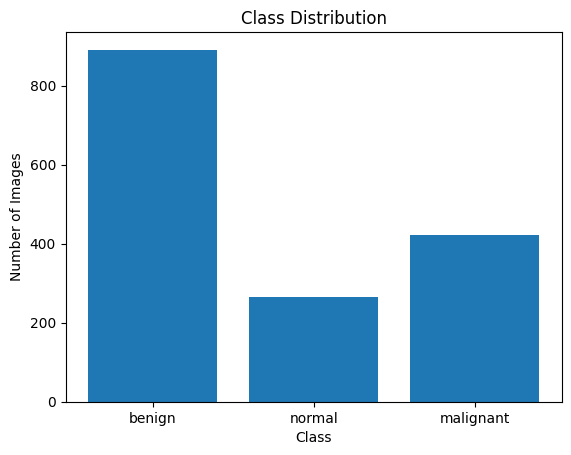

In [6]:
classes = os.listdir(dataset_path)
counts = {}
for c in classes:
    counts[c] = len(os.listdir(os.path.join(dataset_path,c)))
print(counts)
plt.bar(counts.keys(), counts.values())
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [7]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])
dataset = ImageFolder(dataset_path, transform=transform)
print("Total Images:",len(dataset))
print("Classes:",dataset.classes)

Total Images: 1578
Classes: ['benign', 'malignant', 'normal']


In [10]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_data, val_data, test_data = random_split(dataset,[train_size,val_size,test_size])
train_loader = DataLoader(train_data,batch_size=32,shuffle=True)
val_loader = DataLoader(val_data,batch_size=32)
test_loader = DataLoader(test_data,batch_size=32)

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def train_model(model,train_loader,criterion,optimizer,epochs=10):

    model.train()
    for epoch in range(epochs):

        total_loss = 0
        for images,labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs,labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print("Epoch:",epoch+1,"Loss:",total_loss)

In [24]:
def evaluate(model,loader):

    model.eval()
    preds=[]
    true=[]
    with torch.no_grad():

        for images,labels in loader:
            images = images.to(device)
            outputs = model(images)
            _,predicted = torch.max(outputs,1)
            preds.extend(predicted.cpu().numpy())
            true.extend(labels.numpy())

    acc = accuracy_score(true,preds)
    prec = precision_score(true,preds,average='weighted')
    rec = recall_score(true,preds,average='weighted')
    f1 = f1_score(true,preds,average='weighted')

    cm = confusion_matrix(true,preds)

    print("Accuracy:",acc)
    print("Precision:",prec)
    print("Recall:",rec)
    print("F1 Score:",f1)

    sns.heatmap(cm,annot=True)
    plt.show()

    return acc,prec,rec,f1

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch: 1 Loss: 18.933011695742607
Epoch: 2 Loss: 9.523096270859241
Epoch: 3 Loss: 8.374577462673187
Epoch: 4 Loss: 9.257396206259727
Epoch: 5 Loss: 6.866017306223512
Epoch: 6 Loss: 5.345628868788481
Epoch: 7 Loss: 10.64774102717638
Epoch: 8 Loss: 6.428432036191225
Epoch: 9 Loss: 5.704806987196207
Epoch: 10 Loss: 4.99905576556921
Accuracy: 0.8025210084033614
Precision: 0.8327017759810108
Recall: 0.8025210084033614
F1 Score: 0.8068539846424243


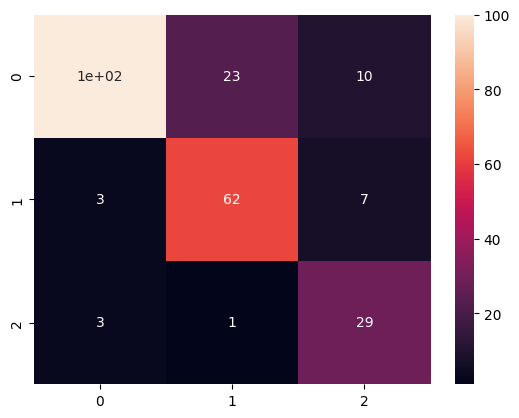

In [25]:
model = resnet18(pretrained=True)
model.fc = torch.nn.Linear(model.fc.in_features,3)
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

train_model(model,train_loader,criterion,optimizer,epochs=10)

baseline_acc, baseline_prec, baseline_rec, baseline_f1 = evaluate(model,test_loader)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch: 1 Loss: 18.96886572241783
Epoch: 2 Loss: 11.033811956644058
Epoch: 3 Loss: 9.625644661486149
Epoch: 4 Loss: 6.79839288815856
Epoch: 5 Loss: 7.5488265454769135
Epoch: 6 Loss: 5.417410600930452
Epoch: 7 Loss: 5.061800539493561
Epoch: 8 Loss: 7.08494133874774
Epoch: 9 Loss: 6.437554452568293
Epoch: 10 Loss: 3.6443289453163743
Accuracy: 0.8739495798319328
Precision: 0.8949516019032197
Recall: 0.8739495798319328
F1 Score: 0.8780046166500655


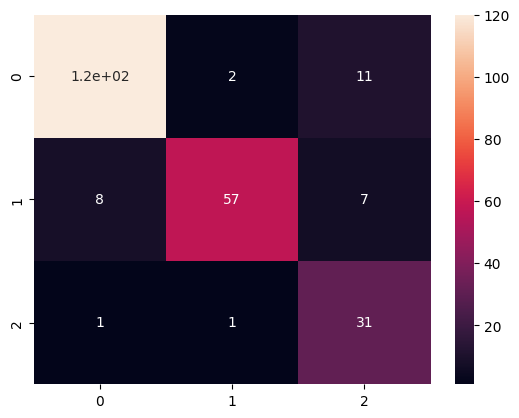

In [26]:
targets = [label for _,label in train_data]
class_sample_count = np.bincount(targets)
weights = 1. / class_sample_count
samples_weight = [weights[t] for t in targets]
sampler = WeightedRandomSampler(samples_weight,len(samples_weight))
train_loader_over = DataLoader(train_data,batch_size=32,sampler=sampler)
model = resnet18(pretrained=True)
model.fc = torch.nn.Linear(model.fc.in_features,3)
model = model.to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
train_model(model,train_loader_over,criterion,optimizer,epochs=10)
over_acc, over_prec, over_rec, over_f1 = evaluate(model,test_loader)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch: 1 Loss: 25.23897585272789
Epoch: 2 Loss: 16.752727523446083
Epoch: 3 Loss: 15.407548159360886
Epoch: 4 Loss: 14.29881438612938
Epoch: 5 Loss: 13.480548188090324
Epoch: 6 Loss: 12.904882252216339
Epoch: 7 Loss: 12.908629223704338
Epoch: 8 Loss: 11.568878680467606
Epoch: 9 Loss: 11.21400572359562
Epoch: 10 Loss: 11.528323233127594
Accuracy: 0.9033613445378151
Precision: 0.9086390653822505
Recall: 0.9033613445378151
F1 Score: 0.9036552617867497


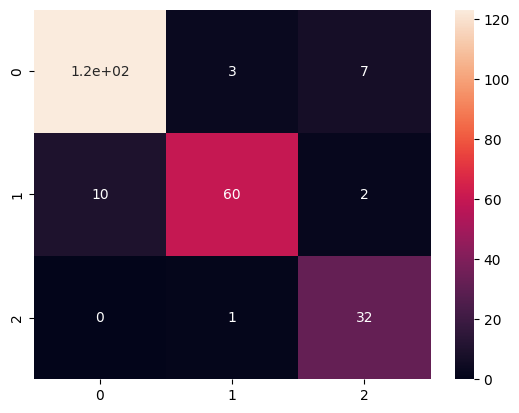

In [27]:
transform_aug = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(10),
    transforms.ToTensor()
])
dataset_aug = ImageFolder(dataset_path,transform=transform_aug)

train_size = int(0.7 * len(dataset_aug))
val_size = int(0.15 * len(dataset_aug))
test_size = len(dataset_aug) - train_size - val_size

train_data_aug, val_data_aug, test_data_aug = random_split(dataset_aug,[train_size,val_size,test_size])

train_loader_aug = DataLoader(train_data_aug,batch_size=32,shuffle=True)
model = resnet18(pretrained=True)
model.fc = torch.nn.Linear(model.fc.in_features,3)
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

train_model(model,train_loader_aug,criterion,optimizer,epochs=10)

aug_acc, aug_prec, aug_rec, aug_f1 = evaluate(model,test_loader)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch: 1 Loss: 12.758954420685768
Epoch: 2 Loss: 6.100001849234104
Epoch: 3 Loss: 4.511513717472553
Epoch: 4 Loss: 3.6130125373601913
Epoch: 5 Loss: 2.882127445191145
Epoch: 6 Loss: 2.176532408222556
Epoch: 7 Loss: 1.3366716434247792
Epoch: 8 Loss: 1.467812252114527
Epoch: 9 Loss: 2.1601930359611288
Epoch: 10 Loss: 1.3913601688109338
Accuracy: 0.8445378151260504
Precision: 0.8744374183403183
Recall: 0.8445378151260504
F1 Score: 0.8475199594007644


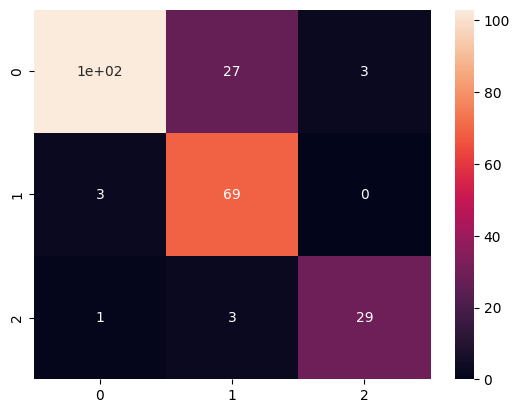

In [28]:
class FocalLoss(torch.nn.Module):

    def __init__(self,gamma=2):
        super(FocalLoss,self).__init__()
        self.gamma = gamma

    def forward(self,inputs,targets):

        ce_loss = torch.nn.functional.cross_entropy(inputs,targets,reduction='none')

        pt = torch.exp(-ce_loss)

        loss = ((1-pt)**self.gamma * ce_loss).mean()

        return loss
model = resnet18(pretrained=True)
model.fc = torch.nn.Linear(model.fc.in_features,3)
model = model.to(device)

criterion = FocalLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

train_loader_focal = DataLoader(train_data,batch_size=32,shuffle=True)

train_model(model,train_loader_focal,criterion,optimizer,epochs=10)

focal_acc, focal_prec, focal_rec, focal_f1 = evaluate(model,test_loader)

In [29]:
results = pd.DataFrame({

"Method":["Baseline","Oversampling","Augmentation","Focal Loss"],

"Accuracy":[baseline_acc, over_acc, aug_acc, focal_acc],

"Precision":[baseline_prec, over_prec, aug_prec, focal_prec],

"Recall":[baseline_rec, over_rec, aug_rec, focal_rec],

"F1":[baseline_f1, over_f1, aug_f1, focal_f1]

})

print(results)

         Method  Accuracy  Precision    Recall        F1
0      Baseline  0.802521   0.832702  0.802521  0.806854
1  Oversampling  0.873950   0.894952  0.873950  0.878005
2  Augmentation  0.903361   0.908639  0.903361  0.903655
3    Focal Loss  0.844538   0.874437  0.844538  0.847520


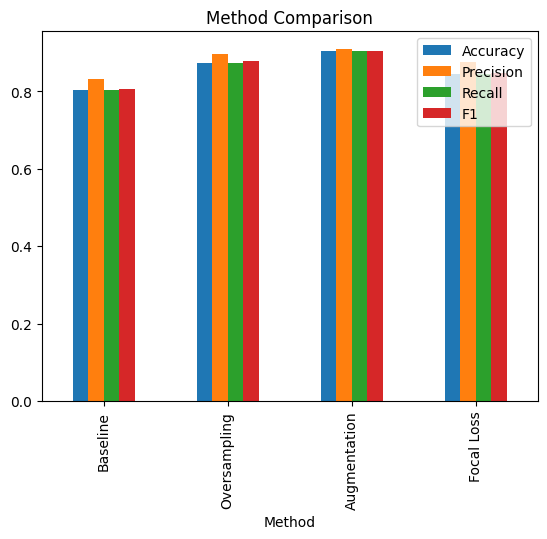

In [30]:
results.set_index("Method").plot(kind="bar")

plt.title("Method Comparison")

plt.show()